In [129]:
# load the K562 lentiMPRA single-seq ISM (saturation-mutagenesis) maps for one seed
# gradient-corrected (mean-centered across channels) -- analog of hypothetical DeepLIFT
import sys, os, numpy as np, pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
sys.path.append("/grid/koo/home/pmantill/projects/VBI/init_impliment/scripts")
from fast_logo import fast_logo

seam_dir = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
peak = "peak27535_Reversed"               # top K562 lentiMPRA seed (seam_seeds.csv)

lib    = "100k"                           # <-- switch library size here: "100k" or "200k"
suffix = {"100k": "", "200k": "_200k"}[lib]

with h5py.File(f"{seam_dir}/ism{suffix}/{peak}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4) ISM, mean-centered across channels
    predictions  = f["predictions"][:]    # (N,) self-prediction of each mutant

with h5py.File(f"{seam_dir}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    wt_sequence = f["wt_sequence"][:]     # (230, 4) with 15bp adapters

wt_onehot = wt_sequence[15:215]           # variable region matches attributions axis
wt_attr   = attributions[0]               # WT attribution map (index 0)

# flatten: each Lx4 attribution map -> one observation in R^D, D=4L
L = attributions.shape[1]
X = attributions.reshape(attributions.shape[0], -1).astype(np.float32)   # (N, 4L)
N, D = X.shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.from_numpy(X).to(device)
var_data = X.var(0) + 1e-8                 # (D,) global per-dim variance (bg cov seed)
print(f"[{lib}] N={N:,}  D={D} (=4*{L})  device={device}")

[100k] N=100,000  D=800 (=4*200)  device=cuda


In [130]:
# ----- hyperparameters (mixture side matches free_bay_GMM.ipynb: K=200, alpha0=1e-3) -----
J        = 4        # latent (foreground code) dimension
K        = 200       # initial number of GMM components (sparse Dirichlet prunes unused)
alpha0   = 1e-3      # Dirichlet concentration (alpha0 < 1 -> sparse -> learns K)
hidden   = 512       # MLP width
seed     = 9
torch.manual_seed(seed); rng = np.random.default_rng(seed)



class VAE_GMM(nn.Module):
    """VAE over the foreground f=decoder(z); shared bg Gaussian N(mu_b,sigma_b^2) added
    before the reconstruction; GMM(K) prior on z with a Dirichlet(alpha) posterior on pi."""
    def __init__(self, D, J, K, alpha0, hidden, var_data):
        super().__init__()
        self.D, self.J, self.K, self.alpha0 = D, J, K, alpha0
        # encoder q(z|x)=N(mu_z, diag sigma_z^2)
        self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        # decoder p(f|z) -> foreground map in R^D
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, D))
        # shared background Gaussian: free mean starts at ZERO (free-bg variant); cov is ISOTROPIC
        self.mu_b     = nn.Parameter(torch.zeros(D))
        self.log_var_b = nn.Parameter(torch.tensor(float(np.log(var_data.mean()))))   # scalar
        # GMM prior components in latent space
        self.mu_c     = nn.Parameter(0.1 * torch.randn(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        # q(pi)=Dir(alpha). A BUFFER, not a Parameter: alpha is a natural parameter of the Dirichlet
        # and is set by the closed-form M-step, so it needs no positivity reparameterization and must
        # not be seen by the optimizer. (The softplus(alpha_raw) form only made sense for SGD on alpha.)
        self.register_buffer("alpha_", torch.full((K,), alpha0 + 1.0))

    @property
    def alpha(self):
        return self.alpha_

    @torch.no_grad()
    def m_step_alpha(self, Nk):
        """Exact ELBO maximizer for the Dirichlet posterior: alpha_k = alpha0 + N_k."""
        self.alpha_.copy_(self.alpha0 + torch.as_tensor(Nk, dtype=torch.float32, device=self.alpha_.device))

    def encode(self, x):
        h = self.enc(x)
        return self.enc_mu(h), self.enc_lv(h)

    def recon_loss(self, x):
        # STACKED-AUTOENCODER warmup: reconstruction (MSE) ONLY -- deterministic z=mu_z, no reparam, no KL
        mu_z, _ = self.encode(x)
        recon = self.dec(mu_z) + self.mu_b
        return ((x - recon)**2).sum(-1).mean()

    def forward(self, x, n_total):
        mu_z, lv_z = self.encode(x)                              # (B,J)
        z = mu_z + torch.randn_like(mu_z) * torch.exp(0.5 * lv_z)
        recon = self.dec(z) + self.mu_b                          # f + b  (mean of x)

        # reconstruction: log p(x-b|z) = log N(x; recon, sigma_b^2 I)
        log_p_x = -0.5 * (np.log(2*np.pi) + self.log_var_b
                          + (x - recon)**2 * torch.exp(-self.log_var_b)).sum(-1)   # (B,)

        # KL[ q(z|x) || N(mu_k,sigma_k^2) ] for every component -> (B,K)
        lv_z_e, mu_z_e = lv_z[:, None, :], mu_z[:, None, :]      # (B,1,J)
        lv_c, mu_c     = self.log_var_c[None], self.mu_c[None]   # (1,K,J)
        KL_k = 0.5 * (lv_c - lv_z_e
                      + (torch.exp(lv_z_e) + (mu_z_e - mu_c)**2) * torch.exp(-lv_c)
                      - 1.0).sum(-1)                              # (B,K)

        alpha   = self.alpha
        Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())   # (K,) E_q[log pi]
        log_un  = Elog_pi[None] - KL_k                                # (B,K)
        log_gamma = log_un - torch.logsumexp(log_un, 1, keepdim=True)
        gamma = log_gamma.exp().detach()                             # responsibilities (E-step)

        klz_term = -(gamma * KL_k).sum(-1)                          # -sum_k gamma_k KL_k
        cat_term = (gamma * (Elog_pi[None] - log_gamma)).sum(-1)    #  sum_k gamma_k log(pi_k/gamma_k)
        elbo_n   = log_p_x + klz_term + cat_term                    # (B,)

        # Dirichlet KL[ q(pi) || Dir(alpha0) ]  (global; scaled per-sample by 1/N)
        kl_pi = (torch.lgamma(alpha.sum()) - torch.lgamma(alpha).sum()
                 - torch.lgamma(torch.tensor(self.K * alpha0, device=x.device))
                 + self.K * torch.lgamma(torch.tensor(alpha0, device=x.device))
                 + ((alpha - alpha0) * Elog_pi).sum())

        loss = -elbo_n.mean() + kl_pi / n_total
        return loss, elbo_n.mean().detach(), gamma

model = VAE_GMM(D, J, K, alpha0, hidden, var_data).to(device)
print(model)

VAE_GMM(
  (enc): Sequential(
    (0): Linear(in_features=800, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
  )
  (enc_mu): Linear(in_features=512, out_features=4, bias=True)
  (enc_lv): Linear(in_features=512, out_features=4, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=800, bias=True)
  )
)


warmup epoch   0  recon MSE/n 3.08807


warmup epoch   5  recon MSE/n 2.58146
warmup epoch  10  recon MSE/n 2.49789
warmup epoch  15  recon MSE/n 2.45018
warmup epoch  20  recon MSE/n 2.41703
warmup epoch  25  recon MSE/n 2.39498
warmup epoch  29  recon MSE/n 2.37989


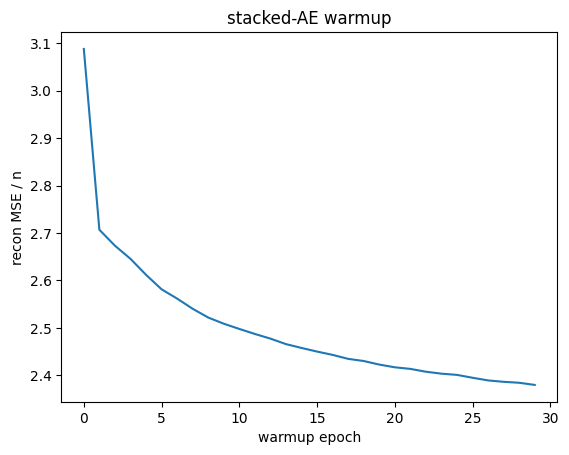

In [131]:
# ----- WARMUP: stacked autoencoder -- train encoder+decoder (+bg mean) on RECONSTRUCTION (MSE) ONLY -----
# deterministic z=mu_z, no reparam, no KL term. Just makes the latent meaningful before clustering.
warmup_epochs, warmup_batch, warmup_lr = 30, 256, 1e-3

warm_params = list(model.enc.parameters()) + list(model.enc_mu.parameters()) \
            + list(model.dec.parameters()) + [model.mu_b]
opt_w = torch.optim.Adam(warm_params, lr=warmup_lr)

model.train()
warm_losses = []
for ep in range(warmup_epochs):
    perm = torch.randperm(N, device=device)
    tot = 0.0
    for i in range(0, N, warmup_batch):
        xb = X_t[perm[i:i+warmup_batch]]
        opt_w.zero_grad()
        l = model.recon_loss(xb)
        l.backward(); opt_w.step()
        tot += l.item() * xb.shape[0]
    warm_losses.append(tot / N)
    if ep % 5 == 0 or ep == warmup_epochs - 1:
        print(f"warmup epoch {ep:3d}  recon MSE/n {warm_losses[-1]:.5f}")

plt.plot(warm_losses); plt.xlabel("warmup epoch"); plt.ylabel("recon MSE / n"); plt.title("stacked-AE warmup"); plt.show()

In [132]:
# ----- init: means at K random latent codes, width left at the constructor value (log_var_c = 0) -----
#   mu_c      <- K randomly drawn latent codes (every component starts ON data, following its density)
#   log_var_c <- 0, i.e. sigma = 1, the constructor width
# For global-variance widths instead, swap the zero_() line for:
#   model.log_var_c.copy_(torch.from_numpy(np.log(Z.var(0) + 1e-8).astype(np.float32)).to(device).expand(K, J).contiguous())
model.eval()
with torch.no_grad():
    Z = torch.cat([model.encode(X_t[i:i+4096])[0] for i in range(0, N, 4096)]).cpu().numpy()  # (N,J)

idx0 = rng.choice(N, K, replace=False)                        # K distinct latent codes
with torch.no_grad():
    model.mu_c.copy_(torch.from_numpy(Z[idx0]).to(device))
    model.log_var_c.zero_()                                   # sigma = 1, constructor value

spread = Z.std(0).mean()
sig = np.exp(0.5 * model.log_var_c.detach().cpu().numpy()).mean()
sep = model.mu_c.std().item()
print(f"means=K random codes, log_var_c=0 | latent spread {spread:.3f} | mu_c std={sep:.3f} | "
      f"sigma={sig:.3f} -> sigma/spread {sig/spread:.2f} | separation/width {sep/sig:.3f}")

means=K random codes, log_var_c=0 | latent spread 0.300 | mu_c std=0.335 | sigma=1.000 -> sigma/spread 3.34 | separation/width 0.335


In [133]:
# ----- t=0 readout: the seeded state, BEFORE any gradient step or M-step -----
# The first line the training loop prints is the END of epoch 0 (~390 Adam steps + one M-step), so a
# 200 -> ~15 collapse would happen entirely unobserved. This measures the same "alive" quantity on the
# untrained mixture, so the drop can be attributed to epoch-0 training rather than to the init.
model.eval()
with torch.no_grad():
    Nk0 = torch.zeros(K, device=device)
    for i in range(0, N, 4096):
        _, _, g = model(X_t[i:i+4096], N)
        Nk0 += g.sum(0)
    Z0 = torch.cat([model.encode(X_t[i:i+4096])[0] for i in range(0, N, 4096)]).cpu().numpy()
Nk0 = Nk0.cpu().numpy()
sig0 = np.exp(0.5 * model.log_var_c.detach().cpu().numpy())
spread0 = Z0.std(0).mean()

print(f"t=0  alive(N_k>1) {int((Nk0 > 1).sum()):3d}/{K}")
print(f"t=0  N_k: min {Nk0.min():.2f}  median {np.median(Nk0):.1f}  max {Nk0.max():.0f}")
print(f"t=0  component sigma median {np.median(sig0):.4f}   latent spread {spread0:.4f}"
      f"   -> sigma/spread {np.median(sig0)/spread0:.2f}   (>>1 = every component covers the whole cloud)")

t=0  alive(N_k>1) 200/200
t=0  N_k: min 116.11  median 533.5  max 579
t=0  component sigma median 1.0000   latent spread 0.2997   -> sigma/spread 3.34   (>>1 = every component covers the whole cloud)


loaded cached fit: /grid/koo/home/pmantill/projects/VBI/VAE_gmm/explicit_M/results/peak27535_Reversed.100k.J4.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.pt  (300 epochs, final ELBO 1184.134)


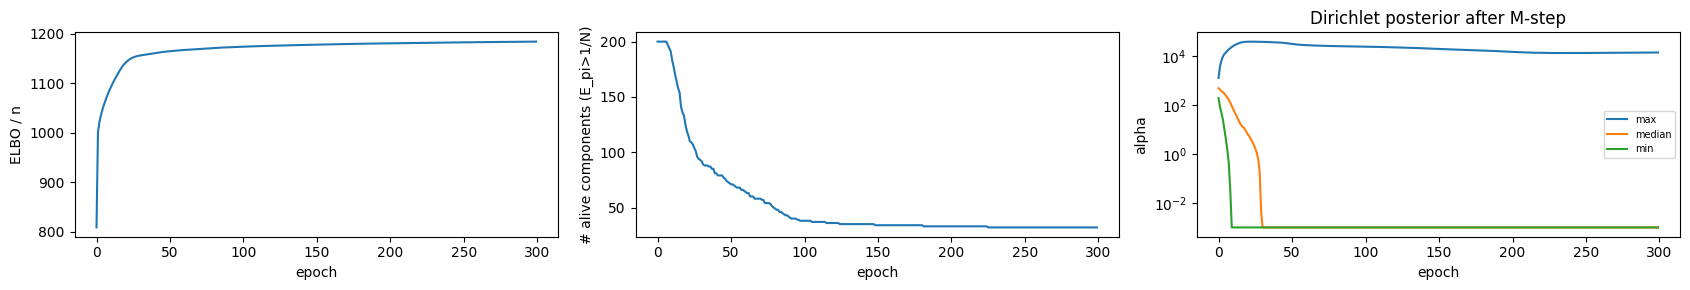

In [134]:
# ----- train full ELBO (Adam for everything EXCEPT alpha) + closed-form M-step on alpha each epoch -----
# THE CHANGE vs scripts/warmup_vae_test.ipynb:
#   - alpha is a buffer, so model.parameters() already excludes it from Adam
#   - responsibilities are accumulated over the epoch into N_k = sum_n gamma_nk
#   - at epoch end: alpha_k <- alpha0 + N_k   (exact ELBO maximizer, not an SGD step)
#   - init: means at K random latent codes, log_var_c = 0  -> '.rfdmu' in the tag
# Everything else (encoder, decoder, mu_b, log_var_b, mu_c, log_var_c) is still Adam as before.
out_dir = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/explicit_M/results"
os.makedirs(out_dir, exist_ok=True)
hp_tag   = f"{peak}.{lib}.J{J}.K{K}.h{hidden}.a{alpha0:g}.warm{warmup_epochs}.mstep.rfdmu.seed{seed}"
ckpt_path = f"{out_dir}/{hp_tag}.pt"

epochs, batch, lr = 100, 256, 1e-4

if os.path.exists(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ck["state_dict"]); elbos = ck["elbos"]; n_alive_hist = ck["n_alive_hist"]
    alpha_hist = ck["alpha_hist"]
    print(f"loaded cached fit: {ckpt_path}  ({len(elbos)} epochs, final ELBO {elbos[-1]:.3f})")
else:
    opt = torch.optim.Adam(model.parameters(), lr=lr)     # alpha is a buffer -> not in parameters()
    elbos, n_alive_hist, alpha_hist = [], [], []
    for ep in range(epochs):
        perm = torch.randperm(N, device=device)
        ep_elbo = 0.0
        Nk = torch.zeros(K, device=device)
        model.train()
        for i in range(0, N, batch):
            xb = X_t[perm[i:i+batch]]
            opt.zero_grad()
            loss, elbo, gamma = model(xb, N)
            loss.backward(); opt.step()
            ep_elbo += float(elbo) * xb.shape[0]
            Nk += gamma.sum(0)                       # gamma is already detached in forward
        model.m_step_alpha(Nk)                       # <-- exact M-step on the Dirichlet posterior
        elbos.append(ep_elbo / N)
        with torch.no_grad():
            a = model.alpha.cpu().numpy()
        E_pi = a / a.sum()
        n_alive_hist.append(int((E_pi > 1.0 / N).sum()))
        alpha_hist.append([float(a.min()), float(np.median(a)), float(a.max())])
        if ep % 10 == 0 or ep == epochs - 1:
            print(f"epoch {ep:3d}  ELBO/n {elbos[-1]:8.3f}  alive(E_pi>1/N) {n_alive_hist[-1]:3d}"
                  f"  alpha [{a.min():.3f}, {np.median(a):.3f}, {a.max():.0f}]")
    torch.save({"state_dict": model.state_dict(), "elbos": elbos, "n_alive_hist": n_alive_hist,
                "alpha_hist": alpha_hist,
                "hp": dict(peak=peak, lib=lib, J=J, K=K, hidden=hidden, alpha0=alpha0,
                           warmup_epochs=warmup_epochs, seed=seed, mstep=True,
                           init="random_codes_logvar0")}, ckpt_path)
    print(f"saved -> {ckpt_path}")

ah = np.array(alpha_hist)
fig, ax = plt.subplots(1, 3, figsize=(17, 3))
ax[0].plot(elbos);        ax[0].set_xlabel("epoch"); ax[0].set_ylabel("ELBO / n")
ax[1].plot(n_alive_hist); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("# alive components (E_pi>1/N)")
ax[2].semilogy(ah[:, 2], label="max"); ax[2].semilogy(ah[:, 1], label="median"); ax[2].semilogy(ah[:, 0], label="min")
ax[2].set_xlabel("epoch"); ax[2].set_ylabel("alpha"); ax[2].legend(fontsize=7)
ax[2].set_title("Dirichlet posterior after M-step")
plt.tight_layout(); plt.show()

In [135]:
# ----- responsibilities over the full dataset (E-step, batched, no grad) -----
model.eval()
gammas = []
with torch.no_grad():
    for i in range(0, N, 4096):
        _, _, g = model(X_t[i:i+4096], N)
        gammas.append(g.cpu())
gamma_all = torch.cat(gammas).numpy()            # (N,K)
Nk   = gamma_all.sum(0)                           # (K,) soft counts
hard = gamma_all.argmax(1)                         # (N,) hard assignment
with torch.no_grad():
    alpha = model.alpha.cpu().numpy()
E_pi = alpha / alpha.sum()

# alpha vs alpha0+N_k: NOT expected to be 0. The M-step used responsibilities accumulated *during*
# the last epoch while the encoder/mixture were still moving; N_k here is recomputed with the final
# model. The gap is how much the assignment shifted over that epoch -- large = not yet converged.
print(f"max |alpha - (alpha0 + Nk)| = {np.abs(alpha - (alpha0 + Nk)).max():.3f}")

pd.DataFrame({
    "Nk_soft": Nk.round(1),
    "Nk_hard": np.bincount(hard, minlength=K),
    "alpha":   alpha.round(3),
    "E_pi":    E_pi.round(4),
}).sort_values("Nk_soft", ascending=False)

max |alpha - (alpha0 + Nk)| = 75.358


,Nk_soft,Nk_hard,alpha,E_pi
64,13634.799805,13938,13663.355469,0.1366
18,10224.000000,10531,10265.787109,0.1027
134,7319.700195,7480,7244.293945,0.0724
79,6021.899902,6027,6036.530762,0.0604
140,4779.600098,5023,4754.728027,0.0475
...,...,...,...,...
195,0.000000,0,0.001000,0.0000
196,0.000000,0,0.001000,0.0000
197,0.000000,0,0.001000,0.0000
198,0.000000,0,0.001000,0.0000


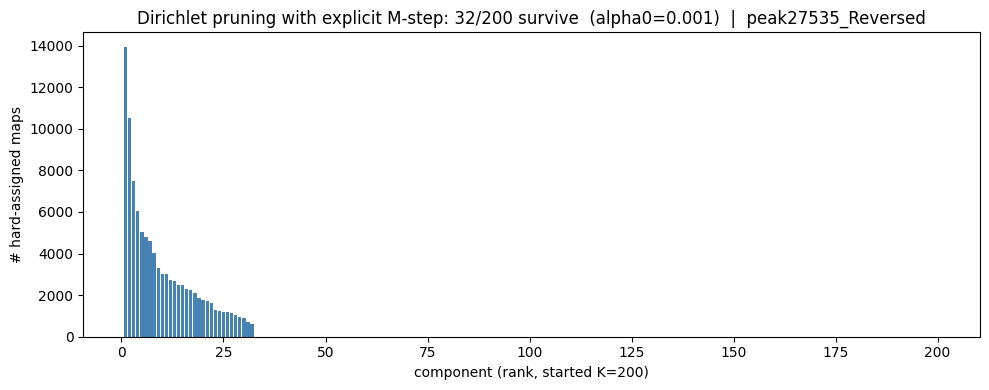

In [136]:
# ----- pruning summary: how many of the K latent components survive -----
hard_counts = np.sort(np.bincount(hard, minlength=K))[::-1]
n_alive = int((hard_counts > 0).sum())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(1, K+1), hard_counts, color="steelblue")
ax.set_xlabel(f"component (rank, started K={K})")
ax.set_ylabel("# hard-assigned maps")
ax.set_title(f"Dirichlet pruning with explicit M-step: {n_alive}/{K} survive  (alpha0={alpha0:g})  |  {peak}")
plt.tight_layout(); plt.show()

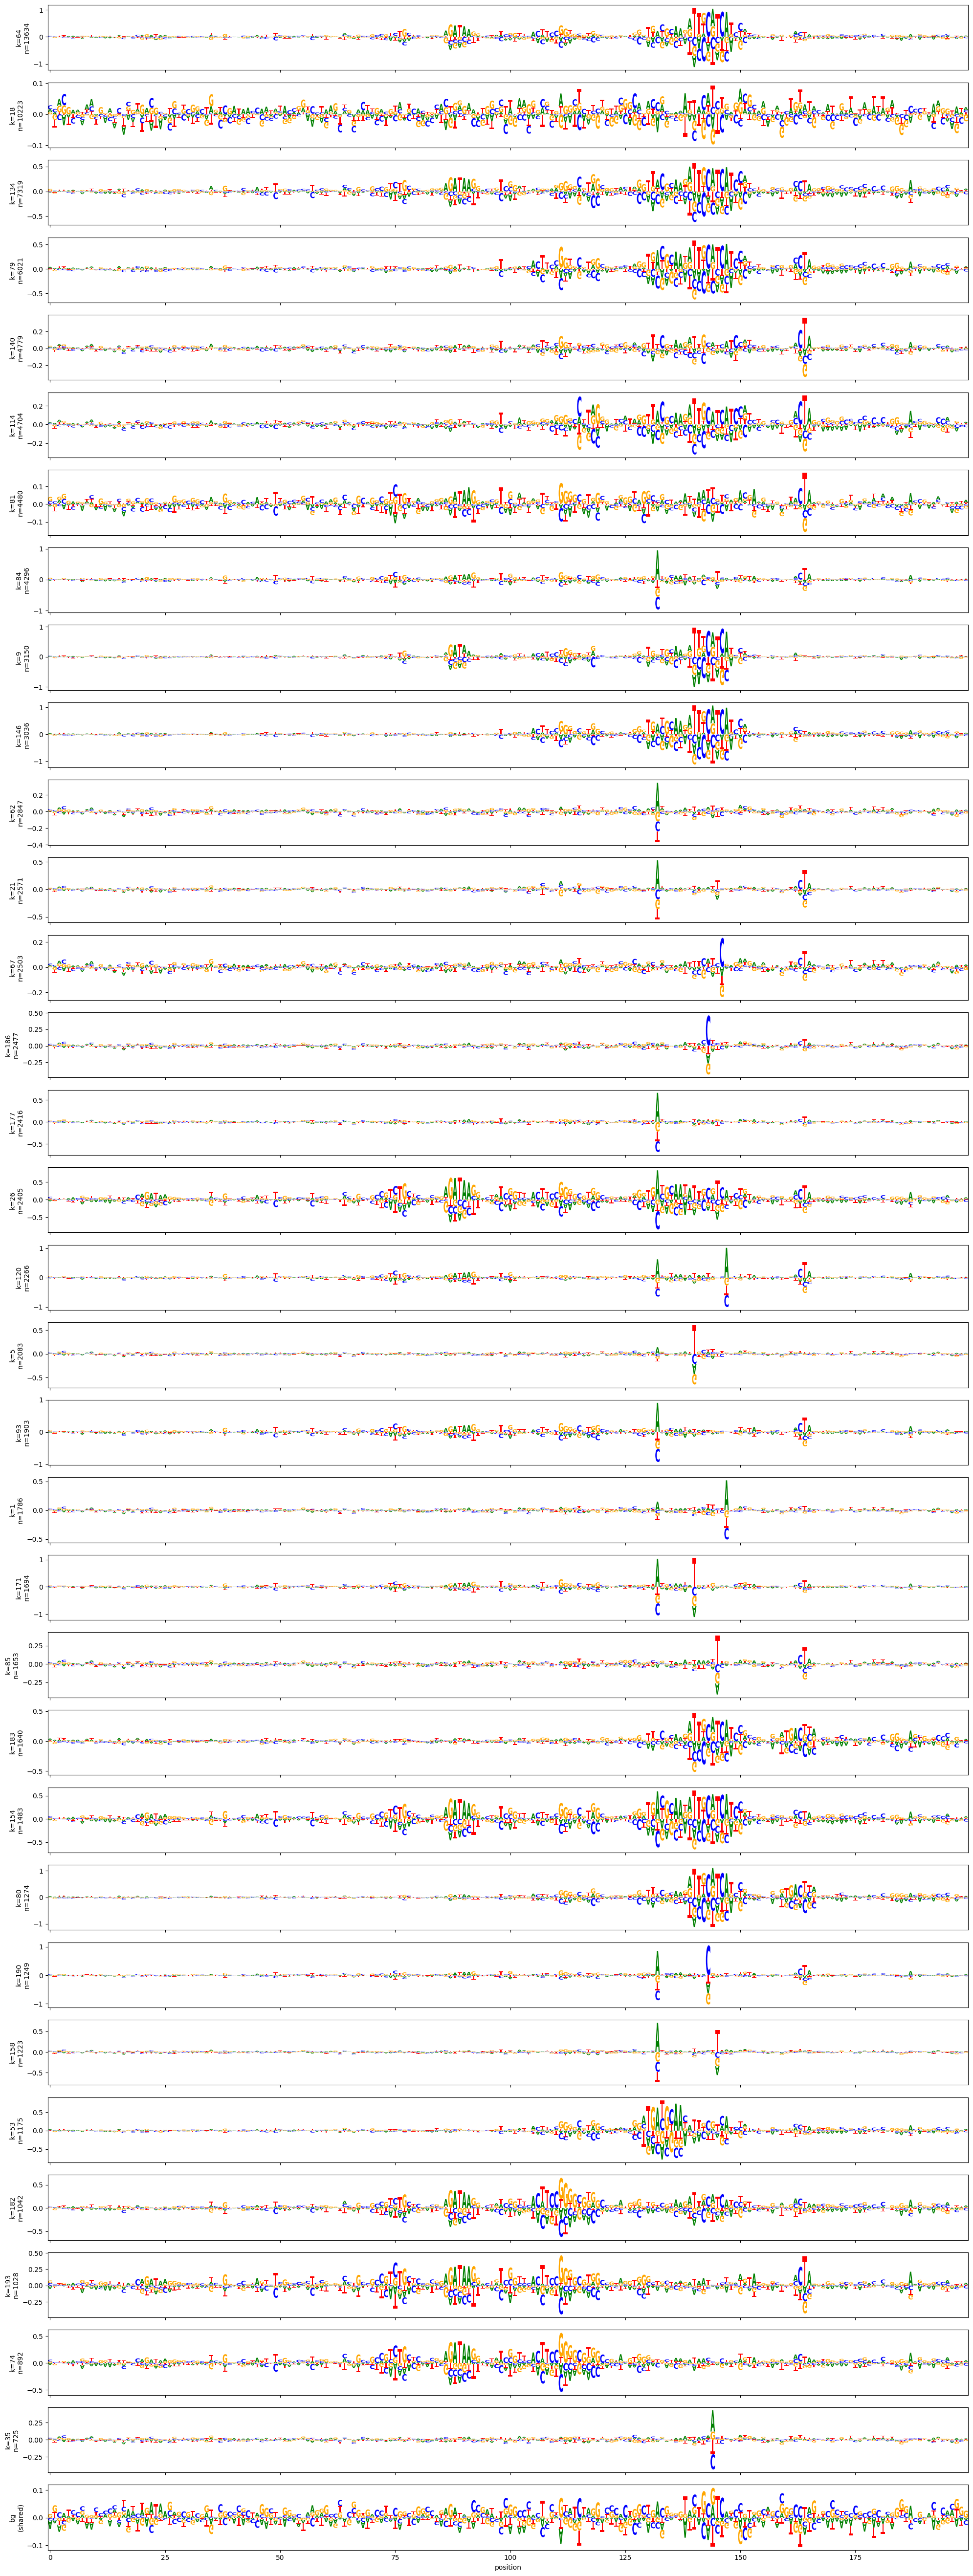

In [137]:
# ----- per-component foreground logos: decode the component mean mu_k -> f_k = decoder(mu_k) -----
# shared background mu_b shown last. Only alive components (largest first).
order = np.argsort(-Nk)
order = [k for k in order if Nk[k] > 1.0]          # drop pruned components
with torch.no_grad():
    fg_means = model.dec(model.mu_c[order].to(device)).cpu().numpy().reshape(len(order), L, 4)
    bg_map   = model.mu_b.detach().cpu().numpy().reshape(L, 4)

fig, axes = plt.subplots(len(order)+1, 1, figsize=(20, 1.6*(len(order)+1)), sharex=True)
axes = np.atleast_1d(axes)
for ax, k, fmap in zip(axes[:-1], order, fg_means):
    fast_logo(fmap, ax=ax)
    ax.set_ylabel(f"k={k}\nn={int(Nk[k])}")
fast_logo(bg_map, ax=axes[-1]); axes[-1].set_ylabel("bg\n(shared)"); axes[-1].set_xlabel("position")
plt.tight_layout(); plt.show()

saved figure -> /grid/koo/home/pmantill/projects/VBI/VAE_gmm/explicit_M/results/figures/peak27535_Reversed.100k.J4.K200.h512.a0.001.warm30.mstep.rfdmu.seed9.fg_bg_compare.png


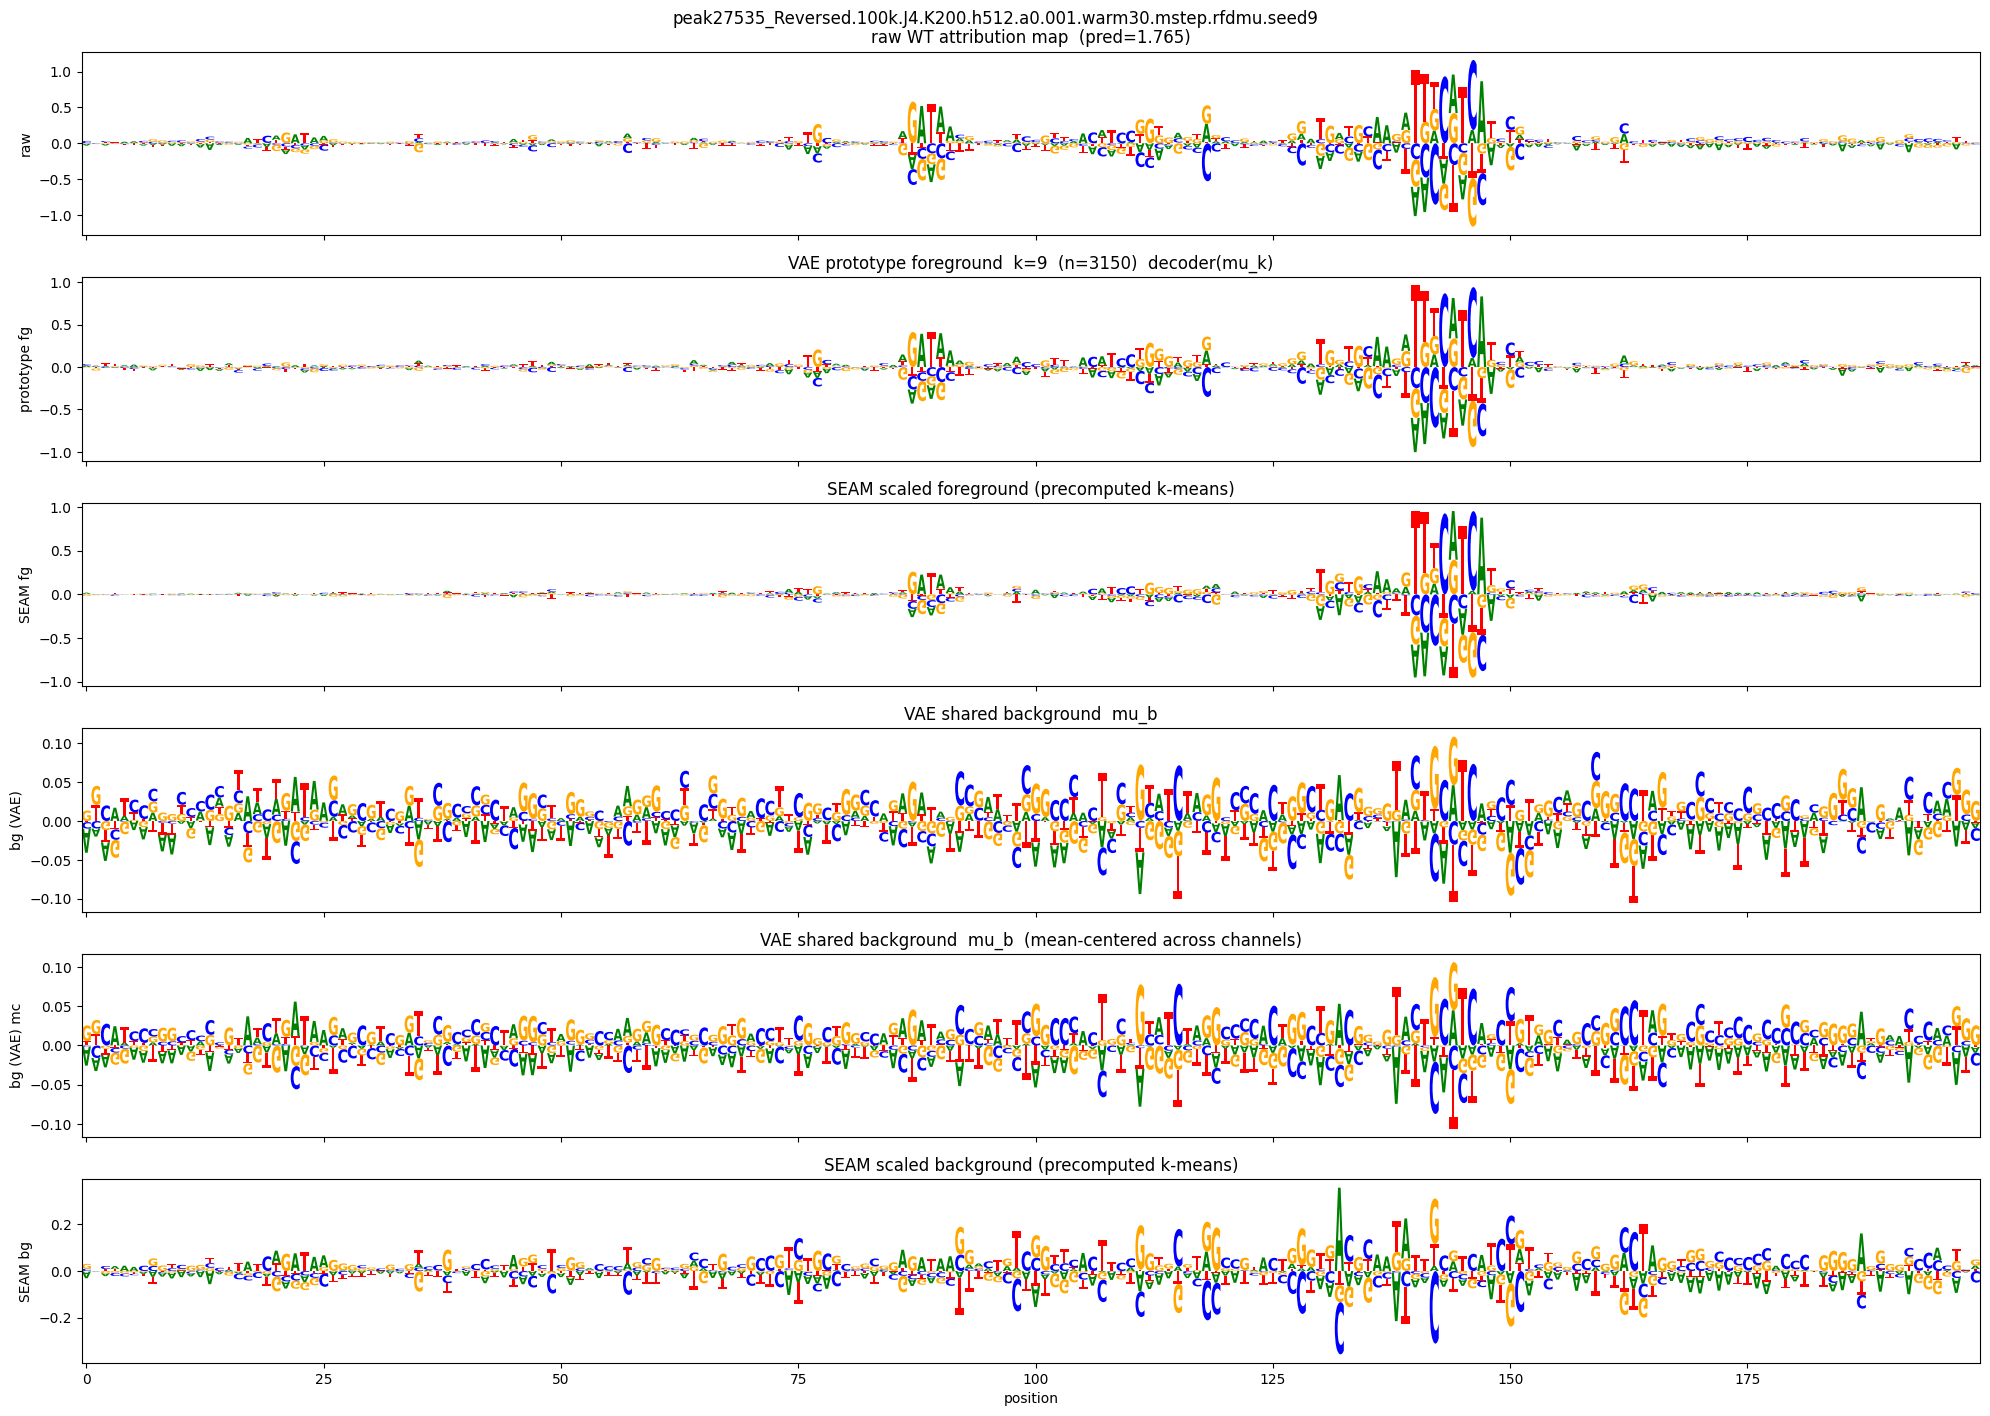

In [138]:
# ----- WT (index 0): raw map vs its cluster's PROTOTYPE foreground, SEAM foreground, background -----
k_wt = int(hard[0])
with torch.no_grad():
    proto_fg = model.dec(model.mu_c[k_wt:k_wt+1].to(device)).cpu().numpy().reshape(L, 4)
    bg_mean  = model.mu_b.detach().cpu().numpy().reshape(L, 4)
bg_mean_mc = bg_mean - bg_mean.mean(-1, keepdims=True)   # mu_b mean-centered across channels

seam_dir_pk = f"{seam_dir}/foregrounds{suffix}/{peak}"
seam_fg = np.load(f"{seam_dir_pk}/foreground_scaled.npy")                 # SEAM scaled foreground
seam_bg = np.load(f"{seam_dir_pk}/average_background_scaled.npy")         # SEAM scaled background

panels = [
    (wt_attr,    "raw",            f"raw WT attribution map  (pred={predictions[0]:.3f})"),
    (proto_fg,   "prototype fg",   f"VAE prototype foreground  k={k_wt}  (n={int(Nk[k_wt])})  decoder(mu_k)"),
    (seam_fg,    "SEAM fg",        "SEAM scaled foreground (precomputed k-means)"),
    (bg_mean,    "bg (VAE)",       "VAE shared background  mu_b"),
    (bg_mean_mc, "bg (VAE) mc",    "VAE shared background  mu_b  (mean-centered across channels)"),
    (seam_bg,    "SEAM bg",        "SEAM scaled background (precomputed k-means)"),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.4*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    fast_logo(m, ax=ax); ax.set_ylabel(ylab); ax.set_title(title)
axes[-1].set_xlabel("position")
fig.suptitle(hp_tag)
plt.tight_layout()

fig_dir = f"{out_dir}/figures"; os.makedirs(fig_dir, exist_ok=True)
fig_path = f"{fig_dir}/{hp_tag}.fg_bg_compare.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"saved figure -> {fig_path}")
plt.show()

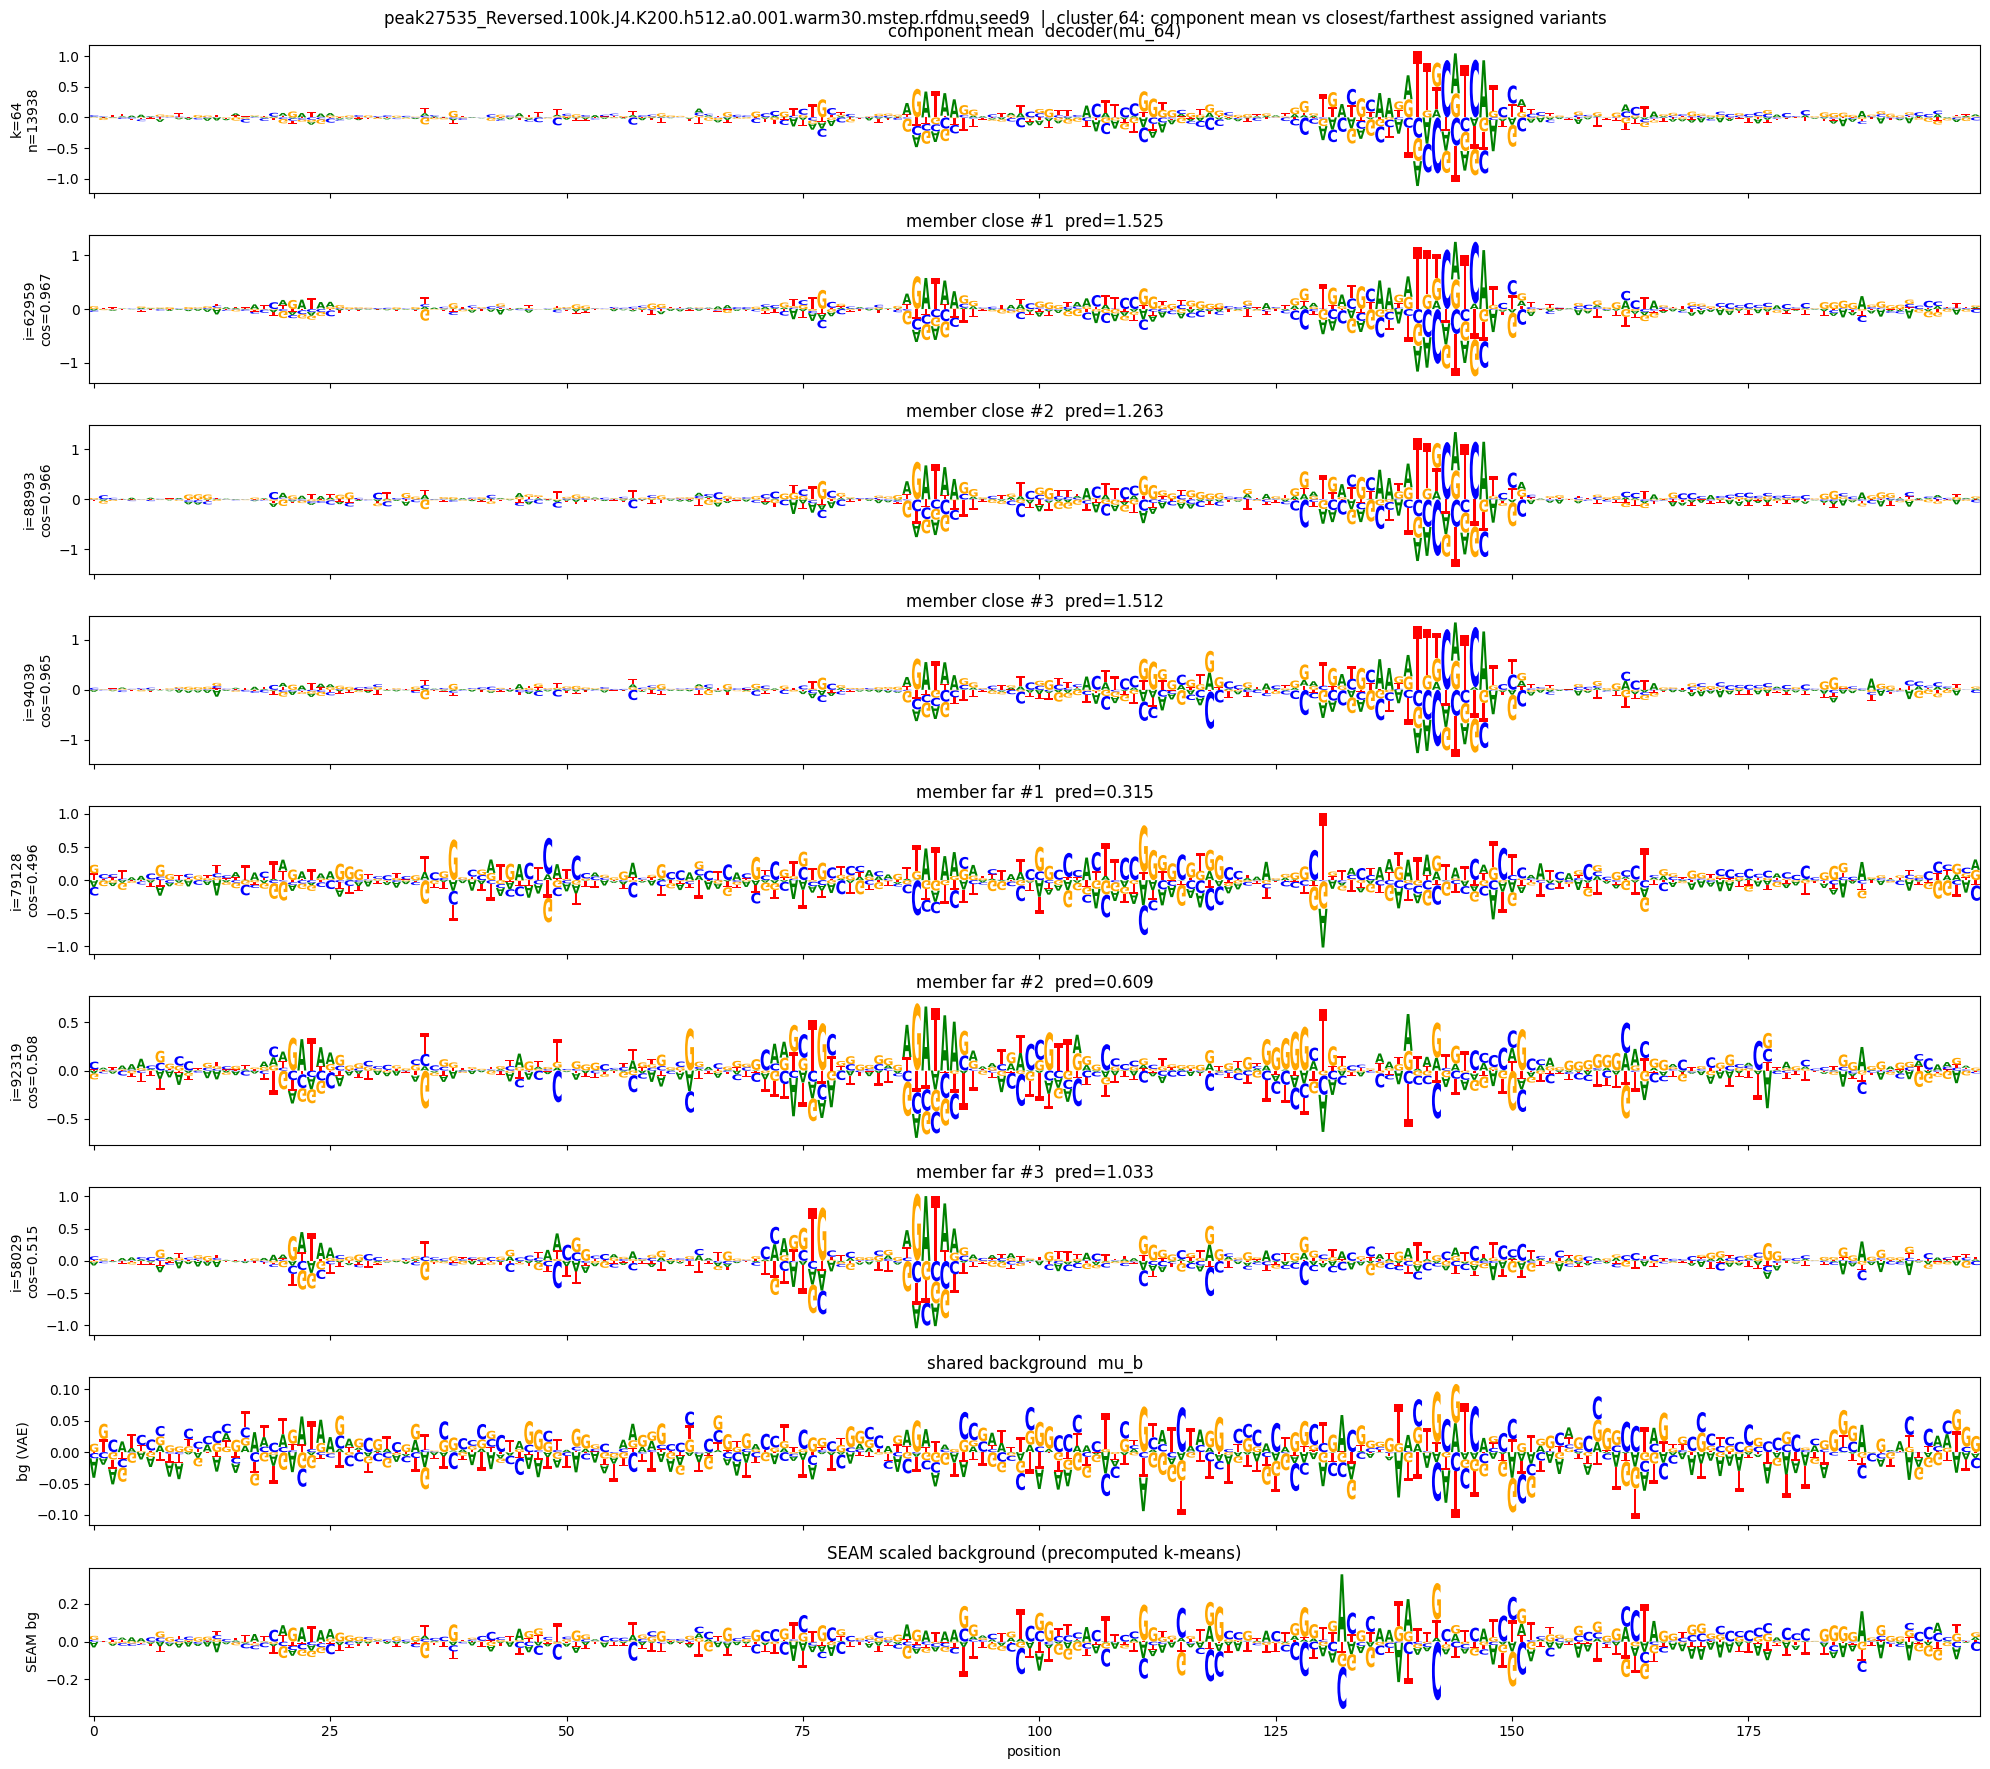

In [139]:
# ----- inspect ONE cluster: its component mean mu_k vs the variants hard-assigned to it -----
# (within-cluster spread: 3 closest + 3 farthest member maps to the component mean, by cosine)
sel_k = int(np.argmax(Nk))          # <-- pick a cluster here (default: largest)

members = np.where(hard == sel_k)[0]                      # variants hard-assigned to this cluster
with torch.no_grad():
    comp_fg = model.dec(model.mu_c[sel_k:sel_k+1].to(device)).cpu().numpy().reshape(L, 4)
    bg_mean = model.mu_b.detach().cpu().numpy().reshape(L, 4)

c_vec = comp_fg.ravel(); c_vec = c_vec / (np.linalg.norm(c_vec) + 1e-12)
m_vec = X[members]; m_vec = m_vec / (np.linalg.norm(m_vec, axis=1, keepdims=True) + 1e-12)
cos   = m_vec @ c_vec                                     # (n_members,)
rank  = np.argsort(-cos)                                   # high -> low similarity
near  = members[rank[:3]]                                  # 3 most typical members
far   = members[rank[-3:][::-1]]                           # 3 most atypical members
cos_of = dict(zip(members.tolist(), cos.tolist()))

seam_dir_pk = f"{seam_dir}/foregrounds{suffix}/{peak}"
seam_bg = np.load(f"{seam_dir_pk}/average_background_scaled.npy")

panels  = [(comp_fg, f"k={sel_k}\nn={len(members)}", f"component mean  decoder(mu_{sel_k})")]
panels += [(X[i].reshape(L, 4), f"i={i}\ncos={cos_of[i]:.3f}", f"member close #{n+1}  pred={predictions[i]:.3f}") for n, i in enumerate(near)]
panels += [(X[i].reshape(L, 4), f"i={i}\ncos={cos_of[i]:.3f}", f"member far #{n+1}  pred={predictions[i]:.3f}") for n, i in enumerate(far)]
panels += [(bg_mean, "bg (VAE)", "shared background  mu_b"),
           (seam_bg, "SEAM bg",  "SEAM scaled background (precomputed k-means)")]

fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.0*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    fast_logo(m, ax=ax); ax.set_ylabel(ylab); ax.set_title(title)
axes[-1].set_xlabel("position")
fig.suptitle(f"{hp_tag}  |  cluster {sel_k}: component mean vs closest/farthest assigned variants")
plt.tight_layout(); plt.show()

/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


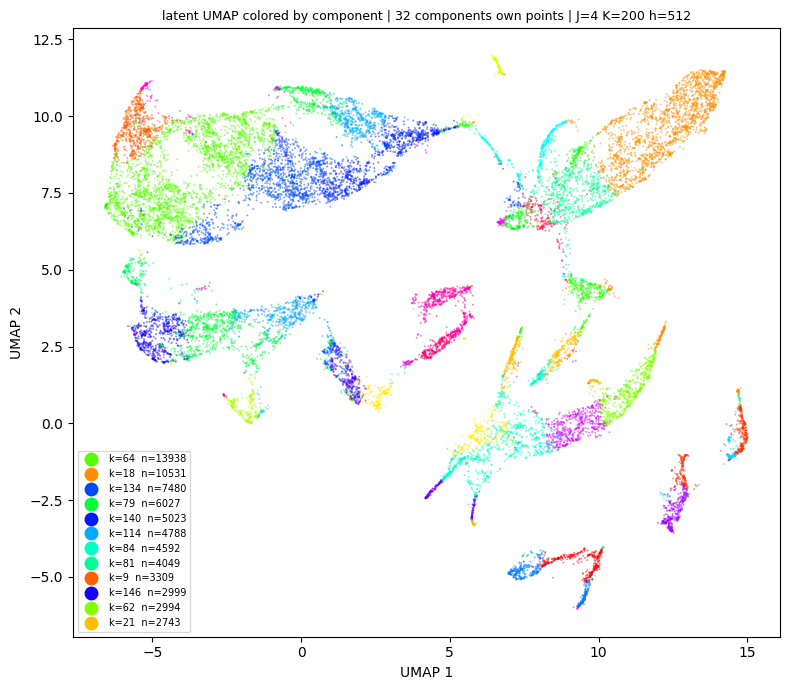

In [140]:
# ----- latent scatter colored by component: is the pruning real? -----
# Real modes    -> each surviving component occupies its OWN region of the embedding.
# Temperature   -> colors are interleaved through one continuous blob, i.e. the components are
#                  arbitrary cuts of a continuum and the survivor count reflects how peaked the
#                  responsibilities are (which J controls), not how many modes the data has.
model.eval()
with torch.no_grad():
    Zf = torch.cat([model.encode(X_t[i:i+4096])[0] for i in range(0, N, 4096)]).cpu().numpy()
sub = np.random.default_rng(0).choice(N, 20000, replace=False)

if J == 2:
    emb, red_name = Zf[sub], "z"          # already 2D -- plot the latent directly, no reduction
else:
    try:
        from umap import UMAP
        reducer, red_name = UMAP(n_neighbors=30, min_dist=0.1, random_state=0), "UMAP"
    except ImportError:   # umap-learn is in Hippo_agft_venv, not necessarily this kernel
        from sklearn.decomposition import PCA
        reducer, red_name = PCA(n_components=2, random_state=0), "PCA"
    emb = reducer.fit_transform(Zf[sub])
lab_sub = hard[sub]

ks = list(np.unique(hard))                                              # components that own points
cols = plt.get_cmap("hsv")(np.linspace(0, 1, len(ks), endpoint=False))  # unique color each, no recycling
kcol = {k: cols[i] for i, k in enumerate(ks)}
sizes = {k: int((hard == k).sum()) for k in ks}
top = sorted(ks, key=lambda k: -sizes[k])[:12]                          # legend for the biggest only

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(emb[:, 0], emb[:, 1], c=[kcol[k] for k in lab_sub], s=2, alpha=0.5, linewidths=0)
if J == 2:                                                              # component means, same colors
    mu = model.mu_c.detach().cpu().numpy()
    ax.scatter(mu[ks, 0], mu[ks, 1], c=[kcol[k] for k in ks], s=90, marker="x", linewidths=2)
ax.set_xlabel(f"{red_name} 1"); ax.set_ylabel(f"{red_name} 2")
ax.set_title(f"latent {red_name} colored by component | {len(ks)} components own points | J={J} K={K} h={hidden}", fontsize=9)
ax.legend(handles=[plt.Line2D([0], [0], marker="o", ls="", color=kcol[k], label=f"k={k}  n={sizes[k]}")
                   for k in top], fontsize=7, markerscale=1.5, loc="best")
plt.tight_layout(); plt.show()

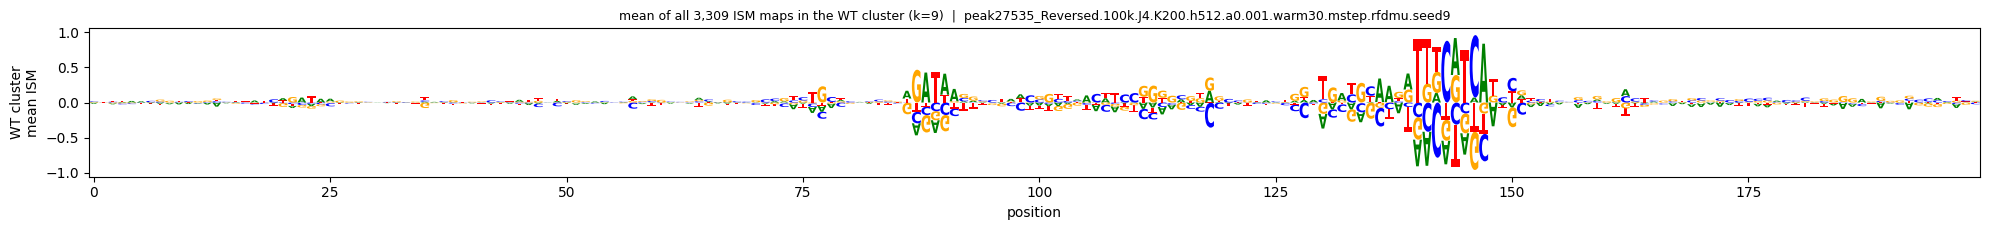

In [141]:
# ----- WT cluster: average of ALL raw ISM maps assigned to it -----
# Empirical counterpart of decoder(mu_k): the mean attribution map over the cluster's members, with
# no model in between. If the cluster is a real mode this averages coherently and keeps its motif
# syntax; if it is a slice of a continuum the members' motifs cancel and the average washes out.
k_wt = int(hard[0])
members_wt = np.where(hard == k_wt)[0]
avg_map = X[members_wt].mean(0).reshape(L, 4)

fig, ax = plt.subplots(figsize=(20, 2.4))
fast_logo(avg_map, ax=ax)
ax.set_ylabel("WT cluster\nmean ISM")
ax.set_xlabel("position")
ax.set_title(f"mean of all {len(members_wt):,} ISM maps in the WT cluster (k={k_wt})  |  {hp_tag}", fontsize=9)
plt.tight_layout(); plt.show()